In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

# Загрузите изображение в оттенках серого sar_1_gray.jpg.


In [21]:
image = cv2.imread("images-20260917T190232Z-1-001/images/sar_1_gray.jpg", cv2.IMREAD_GRAYSCALE)

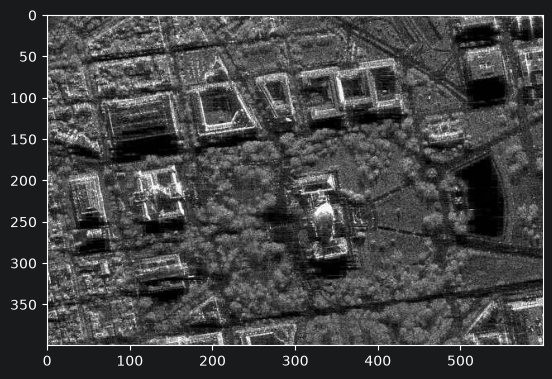

In [22]:
plt.imshow(image, cmap="gray")

# постройте гистограмму

In [23]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

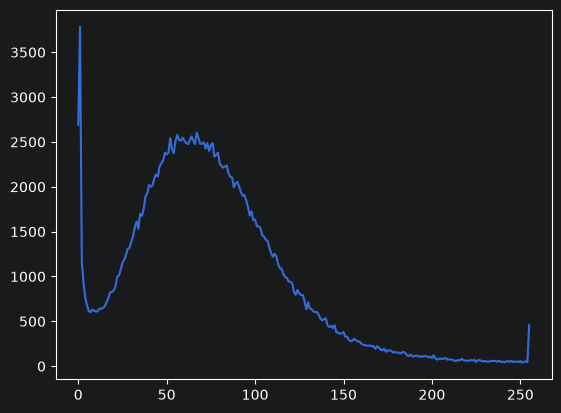

In [24]:
plt.plot(b_hist)

# Алгоритм гамма коррекции


In [25]:
def gamma_correction(image, gamma=1.0):
    norma = image / 255
    corrected_norma = np.power(norma, gamma)
    corrected_image = np.uint8(corrected_norma * 255)
    return corrected_image

# MSE, SSIM

In [26]:
img_light = gamma_correction(image, 0.5)
img_dark = gamma_correction(image, 2.0)

In [31]:
(ssim, diff) = structural_similarity(img_light, img_dark, full=True)
diff = (diff * 255).astype("uint8")
print(f"SSIM: {ssim}")

SSIM: 0.311566788324726


In [32]:
mse = mean_squared_error(img_light, img_dark)
print(f"MSE: {mse}")

MSE: 10962.560175


# алгоритм статистической цветокоррекции

In [33]:
def statistical_color_correction(target, source):
    E_T = np.mean(target)
    D_T = np.std(target)
    E_S = np.mean(source)
    D_S = np.std(source)
    c = E_S + (target.astype(np.float64) - E_T) * (D_S / (D_T + 1e-8))
    c = np.clip(c, 0, 255).astype(np.uint8)
    return c

In [35]:
eq_gray = cv2.equalizeHist(image)
img_stat_corrected = statistical_color_correction(image, eq_gray)

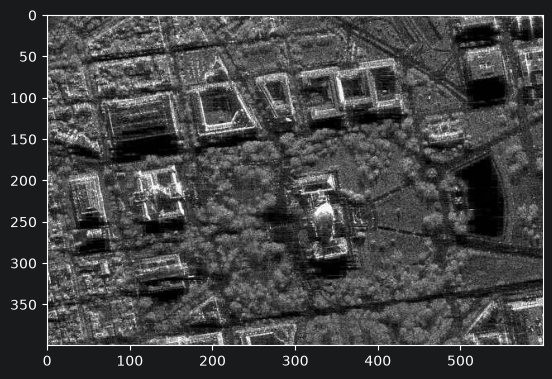

In [36]:
plt.imshow(img_stat_corrected, cmap="gray")